In [ ]:
# # Download image
# 'https://connect-tool.irap.omp.eu/api_creation/SOLO/ADAPT/SUNTIME/20220303T120000/?frame=on&hcs=on&connectivity=on&subpoint=on'

In [ ]:
# 'https://connect-tool.irap.omp.eu/api/SOLO/ADAPT/SUNTIME/20220303T120000/?frame=on&hcs=on&connectivity=on&subpoint=on'

In [ ]:
https://connect-tool.irap.omp.eu/static/connect_img/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20220303T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_fileconnectivity.ascii

https://connect-tool.irap.omp.eu/static/temporary/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20240407T120000_filefieldline.fits
https://connect-tool.irap.omp.eu/static/connect_img/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20240407T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20240407T120000_fileconnectivity.ascii
https://connect-tool.irap.omp.eu/static/connect_img/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20240407T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20240407T120000_filehcs.ascii


https://connect-tool.irap.omp.eu/static/temporary/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20250307T120000_filefieldline.fits
https://connect-tool.irap.omp.eu/static/connect_img/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20250307T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20250307T120000_fileconnectivity.ascii
https://connect-tool.irap.omp.eu/static/connect_img/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20250307T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20250307T120000_filehcs.ascii

https://connect-tool.irap.omp.eu/static/temporary/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_filefieldline.fits
https://connect-tool.irap.omp.eu/static/connect_img/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20220303T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_filehcs.ascii
https://connect-tool.irap.omp.eu/static/connect_img/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20220303T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_fileconnectivity.ascii

In [2]:
import io
import re
import zipfile

import requests
import yaml
import numpy as np
import pandas as pd

BASE_URL = "https://connect-tool.irap.omp.eu"


In [3]:
R_SUN_M  = 6.957e8   # solar radius in metres
AU_M     = 1.496e11  # 1 AU in metres


def build_zip_url(sc: str, coronal: str, mode: str,
                  date_str: str, time_str: str) -> str:
    """
    Construct the direct download URL for an MCT result ZIP.

    ZIP naming convention (confirmed from live API):
        {SC}_PARKER_PFSS_{MODE}_{CORONAL}_SCIENCE_{YYYYMMDD}T{HHMMSS}.zip

    Parameters
    ----------
    sc      : spacecraft, e.g. 'SOLO', 'PSP', 'EARTH', 'STA', 'BEPI'
    coronal : coronal model, e.g. 'ADAPT', 'WSO', 'NSO'
    mode    : propagation mode, e.g. 'SCTIME', 'SUNTIME', 'SCTIMEBW', 'SUNTIMEBW'
    date_str: 'YYYY-MM-DD'
    time_str: 'HHMMSS' - one of 000000, 060000, 120000, 180000
    """
    date_compact = date_str.replace("-", "")
    fname = f"{sc}_PARKER_PFSS_{mode}_{coronal}_SCIENCE_{date_compact}T{time_str}.zip"
    return f"{BASE_URL}/static/zip_files/{fname}"


def fetch_mct_zip(sc: str, coronal: str, mode: str, date_str: str, time_str: str, timeout: int = 60) -> dict[str, bytes]:
    """
    Download the MCT result ZIP and return its contents as a dict.

    Returns
    -------
    dict mapping filename (str) -> raw bytes
    """
    url = build_zip_url(sc, coronal, mode, date_str, time_str)
    print(f"Fetching ZIP: {url}")
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()

    files: dict[str, bytes] = {}
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        for name in zf.namelist():
            files[name] = zf.read(name)

    print(f"  => {len(files)} files in ZIP")
    return files


def get_ascii_text(files: dict, keyword: str) -> bytes | None:
    """Return the bytes of the first ZIP entry whose name contains `keyword`."""
    for name, content in files.items():
        if keyword in name.lower():
            return content
    return None

In [7]:
# -- Configuration ----------------------------------------------------------------
SC        = "SOLO"
CORONAL   = "ADAPT"
PROPAGATION_MODE = "SCTIME"
DATE_STR  = "2022-03-03"
TIME_STR  = "120000"
# ---------------------------------------------------------------------------------

# 1. ZIP download (connectivity, HCS, params, images)
mct_files = fetch_mct_zip(SC, CORONAL, PROPAGATION_MODE, DATE_STR, TIME_STR)

print("\nFiles in ZIP:")
for name in sorted(mct_files):
    size = len(mct_files[name])
    print(f"  {name}  ({size:,} bytes)")


Fetching ZIP: https://connect-tool.irap.omp.eu/static/zip_files/SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000.zip
  => 21 files in ZIP

Files in ZIP:
  SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000_backgroundeui174.png  (115,565 bytes)
  SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000_backgroundeui304.png  (121,776 bytes)
  SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000_backgroundeuv171.png  (123,393 bytes)
  SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000_backgroundeuv193.png  (144,751 bytes)
  SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000_backgroundeuv304.png  (147,029 bytes)
  SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000_backgroundmag.png  (77,818 bytes)
  SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000_backgroundwl.png  (55,806 bytes)
  SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000_filear.json  (7,726 bytes)
  SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000_fileconnectivity.ascii  (1,566 bytes)
  SOLO_PARKER_PF

In [ ]:
def parse_connectivity(content: bytes) -> tuple[dict, pd.DataFrame]:
    """
    Parse *_fileconnectivity.ascii.

    File structure (header lines start with '#'):
        Line 0 : version number
        Line 1 : R_sun in metres
        Line 2 : observer time  (YYYY-MM-DD HH:MM:SS)
        Line 3 : SC_name  R_OBS(m)  CRLT_OBS(deg)  CRLN_OBS(deg)
        Line 4 : npoint_tot  npoint_ssw  npoint_fsw  npoint_m
        Lines 5+: footpoint rows --
                  sw_type  idx  prob(%)  R(m)  CRLT(deg)  CRLN(deg)
                  DIST(m)  HPLT(deg)  HPLN(deg)

    Returns
    -------
    sc_info : dict   Spacecraft position in HGC (Carrington) coordinates.
    footpoints : DataFrame   One row per footpoint, sorted by probability.
    """
    text = content.decode("utf-8", errors="ignore")
    data_lines = [ln for ln in text.splitlines()
                  if ln.strip() and not ln.strip().startswith("#")]

    rsun_m   = float(data_lines[1])
    obs_time = data_lines[2].strip()

    sc_parts = data_lines[3].split()
    sc_info = {
        "name":     sc_parts[0],
        "obs_time": obs_time,
        "R_m":      float(sc_parts[1]),
        "R_AU":     float(sc_parts[1]) / AU_M,
        "R_Rsun":   float(sc_parts[1]) / R_SUN_M,
        "lat_HGC_deg": float(sc_parts[2]),   # CRLT -- heliographic latitude
        "lon_HGC_deg": float(sc_parts[3]),   # CRLN -- Carrington longitude
    }

    npoint_tot = int(data_lines[4].split()[0])

    rows = []
    for line in data_lines[5: 5 + npoint_tot]:
        p = line.split()
        rows.append({
            "sw_type":    p[0],           # M=measured, SSW=slow, FSW=fast
            "idx":        int(p[1]),
            "prob_pct":   float(p[2]),    # probability density (%)
            "R_m":        float(p[3]),
            "R_Rsun":     float(p[3]) / R_SUN_M,
            "lat_HGC_deg": float(p[4]),   # CRLT on photosphere
            "lon_HGC_deg": float(p[5]),   # CRLN on photosphere
            "dist_m":     float(p[6]),    # distance in HPC
            "hplt_deg":   float(p[7]),    # helio-projective latitude
            "hpln_deg":   float(p[8]),    # helio-projective longitude
        })

    footpoints = (pd.DataFrame(rows)
                    .sort_values("prob_pct", ascending=False)
                    .reset_index(drop=True))
    return sc_info, footpoints


def parse_params(content: bytes) -> dict:
    """
    Parse *_fileparam.yml.

    Position values in _fileparam.yml are in km:
        photosphere       = 695700 km  = 1.0 Rsun
        source surface    = 1739250 km = 2.5 Rsun
    Format: [R_km, lon_HGC_deg (CRLN), lat_HGC_deg (CRLT)]
    """
    text = content.decode("utf-8", errors="ignore")
    raw  = yaml.safe_load(text)
    sc_key = next(iter(raw))       # e.g. 'SOLO'
    p = raw[sc_key]

    R_SUN_KM = R_SUN_M / 1000   # 695700 km
    AU_KM    = AU_M    / 1000   # 149600000 km

    def _pos(vals):
        if vals is None:
            return None
        R_km = vals[0]
        return {
            "R_km":        R_km,
            "R_AU":        R_km / AU_KM,
            "R_Rsun":      R_km / R_SUN_KM,
            "lon_HGC_deg": vals[1],   # CRLN
            "lat_HGC_deg": vals[2],   # CRLT
        }

    result = {
        "sc_name": sc_key,
        "sc_position": _pos(p.get("position_sc")),
        "source_surface_subpoints": {
            sw: _pos(vals)
            for sw, vals in (p.get("position_ss") or {}).items()
            if vals is not None
        },
        "photospheric_footpoints": {
            sw: _pos(vals)
            for sw, vals in (p.get("main_connect_point") or {}).items()
            if vals is not None
        },
        "metadata": {
            "date_input":          str(p.get("date_in", "")),
            "coronal_model":       p.get("cmodel"),
            "mag_input":           p.get("magtype"),
            "helio_model":         p.get("hmodel"),
            "source_surface_Rsun": p.get("rss"),
            "polarity":            p.get("polarity", {}),
            "vhelio_km_s":         p.get("vhelio", {}),
            "reliability_score":   p.get("score"),
        },
    }
    return result


def build_field_line_df(sc_info: dict, params: dict) -> pd.DataFrame:
    """
    Assemble a 3-point summary table: SC -> Source Surface -> Photosphere.
    For the actual curved PFSS trace use parse_fieldlines_json().
    """
    rows = []
    rows.append({
        "segment":     "Spacecraft",
        "sw_type":     sc_info["name"],
        "R_AU":        sc_info["R_AU"],
        "R_Rsun":      sc_info["R_Rsun"],
        "lon_HGC_deg": sc_info["lon_HGC_deg"],
        "lat_HGC_deg": sc_info["lat_HGC_deg"],
    })
    for sw, vals in params["source_surface_subpoints"].items():
        rows.append({
            "segment":     "Source-Surface Subpoint",
            "sw_type":     sw,
            "R_AU":        vals.get("R_AU"),
            "R_Rsun":      vals.get("R_Rsun"),
            "lon_HGC_deg": vals["lon_HGC_deg"],
            "lat_HGC_deg": vals["lat_HGC_deg"],
        })
    for sw, vals in params["photospheric_footpoints"].items():
        rows.append({
            "segment":     "Photospheric Footpoint",
            "sw_type":     sw,
            "R_AU":        vals.get("R_AU"),
            "R_Rsun":      vals.get("R_Rsun"),
            "lon_HGC_deg": vals["lon_HGC_deg"],
            "lat_HGC_deg": vals["lat_HGC_deg"],
        })
    return pd.DataFrame(rows)


In [8]:
# -- Parse ZIP files ---------------------------------------------------------------
sc_info, footpoints_df = parse_connectivity(
    get_ascii_text(mct_files, "fileconnectivity")
)
params = parse_params(
    get_ascii_text(mct_files, "fileparam")
)
field_line_df = build_field_line_df(sc_info, params)
meta = params["metadata"]

# -- Coronal field line trace -------------------------------------------------------
# NOTE: The IRAP MCT ZIP does not include a PFSS field line trace.
# The /json_api/ endpoint returns HTML (not JSON data), and the create_json
# endpoint returns 500 for "fieldline". To get the actual PFSS trace,
# one would need to run pfsspy locally with the ADAPT FITS file.
# The plot will use straight-line segments as an approximation.
fieldline_df = None

# -- 1. Spacecraft position ---------------------------------------------------------
print("=" * 65)
print("  1. SPACECRAFT POSITION  (HGC = Heliographic Carrington)")
print("=" * 65)
display(pd.DataFrame([{
    "Spacecraft":           sc_info["name"],
    "Obs Time (UTC)":       sc_info["obs_time"],
    "R [AU]":               f"{sc_info['R_AU']:.4f}",
    "R [Rsun]":             f"{sc_info['R_Rsun']:.2f}",
    "Carrington Lon [deg]": f"{sc_info['lon_HGC_deg']:.3f}",
    "Carrington Lat [deg]": f"{sc_info['lat_HGC_deg']:.3f}",
}]))

# -- 2. Coronal field-line path (3-point summary) ----------------------------------
print("\n" + "=" * 65)
print("  2. CORONAL FIELD-LINE PATH  (SC -> Source Surface -> Photosphere)")
print("     Coordinates: HGC (Carrington lon/lat)")
print("=" * 65)
display(
    field_line_df.style
    .format({
        "R_AU":        lambda v: f"{v:.4f}" if v is not None else "--",
        "R_Rsun":      lambda v: f"{v:.2f}" if v is not None else "--",
        "lon_HGC_deg": "{:.3f}",
        "lat_HGC_deg": "{:.3f}",
    })
    .set_properties(**{"text-align": "center"})
)

# -- 3. Photospheric footpoints with probabilities ---------------------------------
print("\n" + "=" * 65)
print("  3. PHOTOSPHERIC FOOTPOINTS  (from _fileconnectivity.ascii)")
print("     Sorted by probability density (highest first)")
print("     sw_type: M=measured Vsw, SSW=slow, FSW=fast")
print("=" * 65)
display(
    footpoints_df[["sw_type", "prob_pct", "R_Rsun",
                   "lon_HGC_deg", "lat_HGC_deg",
                   "hplt_deg", "hpln_deg"]]
    .style
    .format({
        "prob_pct":    "{:.1f}",
        "R_Rsun":      "{:.3f}",
        "lon_HGC_deg": "{:.3f}",
        "lat_HGC_deg": "{:.3f}",
        "hplt_deg":    "{:.4f}",
        "hpln_deg":    "{:.4f}",
    })
    .bar(subset=["prob_pct"], color="#5fa8d3")
    .set_properties(**{"text-align": "center"})
)

# -- 4. Key metadata ----------------------------------------------------------------
print("\n" + "=" * 65)
print("  4. KEY METADATA")
print("=" * 65)

# Bug fix: use 'is not None' so score=0.0 shows '0.00' instead of 'N/A'
score = meta["reliability_score"]
# Bug fix: polarity None shows 'N/A' instead of the string 'None'
pol_val = meta["polarity"].get("M")
polarity_str = {1: "+1 (outward)", -1: "-1 (inward)"}.get(pol_val, "N/A")
vsw_val = meta["vhelio_km_s"].get("M")
vsw_str = f"{vsw_val:.1f}" if vsw_val is not None else "N/A"

display(pd.DataFrame([{
    "Coronal Model":          meta["coronal_model"],
    "Magnetic Input":         meta["mag_input"],
    "Helio Model":            meta["helio_model"],
    "Source Surface [Rsun]":  meta["source_surface_Rsun"],
    "Polarity (M)":           polarity_str,
    "Vsw (M) [km/s]":         vsw_str,
    "Reliability Score":      f"{score:.2f}" if score is not None else "N/A",
}]))


  1. SPACECRAFT POSITION  (HGC = Heliographic Carrington)


,Spacecraft,Obs Time (UTC),R [AU],R [Rsun],Carrington Lon [deg],Carrington Lat [deg]
0,SOLO,2022-03-03 12:00:00,0.5456,117.32,46.688,-4.151



  2. CORONAL FIELD-LINE PATH  (SC -> Source Surface -> Photosphere)
     Coordinates: HGC (Carrington lon/lat)


,segment,sw_type,R_AU,R_Rsun,lon_HGC_deg,lat_HGC_deg
0,Spacecraft,SOLO,0.5456,117.32,46.688,-4.151
1,Source-Surface Subpoint,M,0.0116,2.50,71.201,-4.151
2,Photospheric Footpoint,M,0.0047,1.00,48.880,-13.971



  3. PHOTOSPHERIC FOOTPOINTS  (from _fileconnectivity.ascii)
     Sorted by probability density (highest first)
     sw_type: M=measured Vsw, SSW=slow, FSW=fast


,sw_type,prob_pct,R_Rsun,lon_HGC_deg,lat_HGC_deg,hplt_deg,hpln_deg
0,M,33.0,1.000,48.500,-14.500,-0.0342,-0.0188
1,M,29.0,1.000,48.500,-13.500,-0.0295,-0.0188
2,M,27.0,1.000,49.500,-13.500,-0.0295,-0.0143
3,M,10.0,1.000,49.500,-14.500,-0.0342,-0.0142
4,M,1.0,1.000,47.500,-14.500,-0.0343,-0.0233



  4. KEY METADATA


,Coronal Model,Magnetic Input,Helio Model,Source Surface [Rsun],Polarity (M),Vsw (M) [km/s],Reliability Score
0,PFSS,ADAPT,PARKER,2.5,-1 (inward),535.0,74.54


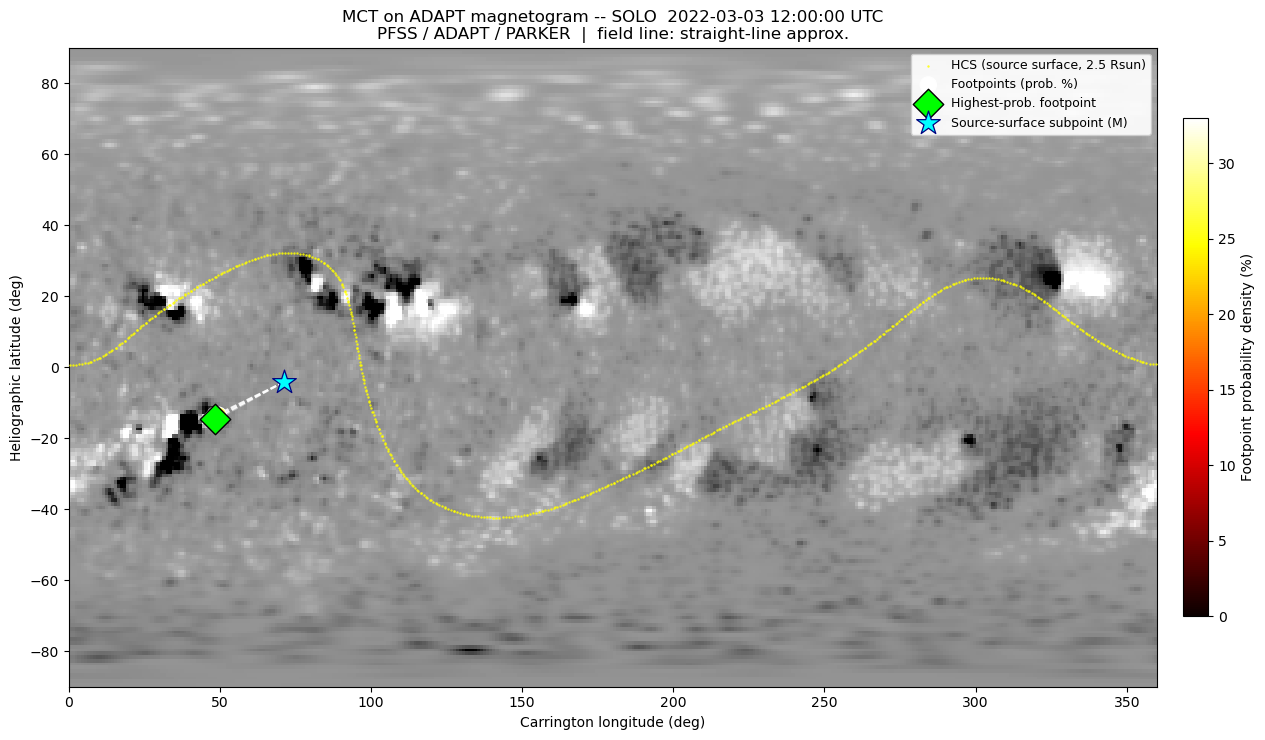

In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image


def parse_hcs(content: bytes) -> pd.DataFrame:
    """Parse *_filehcs.ascii (HCS neutral line at source surface, HGC lon/lat)."""
    rows = []
    for line in content.decode("utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or line.lower().startswith("npoint"):
            continue
        p = line.split()
        rows.append({
            "ipoint":  int(p[0]),
            "R_m":     float(p[1]),
            "lat_deg": float(p[2]),   # CRLT
            "lon_deg": float(p[3]),   # CRLN
        })
    return pd.DataFrame(rows)


def plot_mct_on_adapt_mag(
    mct_files: dict,
    sc_info: dict,
    footpoints_df: pd.DataFrame,
    params: dict,
    meta: dict,
    fieldline_df=None,
    title_suffix: str = "",
):
    """
    Overlay MCT connectivity on the ADAPT magnetogram from the ZIP.

    If fieldline_df is provided (from the JSON API), the actual PFSS coronal
    field line trace is drawn as a curved line. Otherwise, straight dashed
    segments from the source-surface subpoint to footpoints are used as
    a fallback.

    Parameters
    ----------
    fieldline_df : DataFrame with columns lon_HGC_deg, lat_HGC_deg, R_Rsun
        Actual PFSS trace from parse_fieldlines_json(). Pass None for fallback.
    """
    mag_raw = get_ascii_text(mct_files, "backgroundmag")
    if mag_raw is None:
        raise RuntimeError("No backgroundmag PNG in ZIP.")

    hcs_raw = get_ascii_text(mct_files, "filehcs")
    if hcs_raw is None:
        raise RuntimeError("No filehcs.ascii in ZIP.")

    mag_img = Image.open(io.BytesIO(mag_raw)).convert("RGBA")
    hcs_df = parse_hcs(hcs_raw).sort_values("lon_deg")

    fig, ax = plt.subplots(figsize=(14, 7.5))
    ax.imshow(
        mag_img,
        extent=[0.0, 360.0, -90.0, 90.0],
        origin="upper",
        aspect="auto",
        interpolation="nearest",
    )

    # HCS neutral line at source surface (2.5 Rsun)
    ax.scatter(
        hcs_df["lon_deg"],
        hcs_df["lat_deg"],
        s=3,
        c="yellow",
        alpha=0.85,
        linewidths=0,
        zorder=3,
        label="HCS (source surface, 2.5 Rsun)",
    )

    ss_sub = params["source_surface_subpoints"]
    max_p = float(footpoints_df["prob_pct"].max())

    if fieldline_df is not None and not fieldline_df.empty:
        # Actual PFSS coronal field line trace (photosphere -> source surface)
        fl = fieldline_df.sort_values("R_Rsun")
        ax.plot(
            fl["lon_HGC_deg"],
            fl["lat_HGC_deg"],
            color="white",
            linewidth=2.0,
            alpha=0.95,
            zorder=5,
            label="PFSS coronal field line",
        )
    else:
        # Fallback: straight dashed segments from source-surface to footpoints
        for _sw, ss_v in ss_sub.items():
            lon_ss = ss_v["lon_HGC_deg"]
            lat_ss = ss_v["lat_HGC_deg"]
            for _, fp in footpoints_df.iterrows():
                alpha = 0.2 + 0.75 * (fp["prob_pct"] / max_p)
                ax.plot(
                    [lon_ss, fp["lon_HGC_deg"]],
                    [lat_ss, fp["lat_HGC_deg"]],
                    color="white",
                    linestyle="--",
                    linewidth=1.2,
                    alpha=alpha,
                    zorder=4,
                )

    # Photospheric footpoints coloured by probability
    norm = mcolors.Normalize(vmin=0.0, vmax=max_p)
    sc_pts = ax.scatter(
        footpoints_df["lon_HGC_deg"],
        footpoints_df["lat_HGC_deg"],
        c=footpoints_df["prob_pct"],
        cmap="hot",
        norm=norm,
        s=140,
        marker="o",
        edgecolors="white",
        linewidths=0.8,
        zorder=6,
        label="Footpoints (prob. %)",
    )
    cbar = fig.colorbar(sc_pts, ax=ax, shrink=0.78, pad=0.02)
    cbar.set_label("Footpoint probability density (%)")

    # Highest-probability footpoint
    best = footpoints_df.iloc[0]
    ax.scatter(
        best["lon_HGC_deg"],
        best["lat_HGC_deg"],
        s=240,
        marker="D",
        facecolors="lime",
        edgecolors="black",
        linewidths=1.0,
        zorder=8,
        label="Highest-prob. footpoint",
    )

    # Source-surface subpoint(s)
    for sw, ss_v in ss_sub.items():
        ax.scatter(
            ss_v["lon_HGC_deg"],
            ss_v["lat_HGC_deg"],
            s=320,
            marker="*",
            c="cyan",
            edgecolors="navy",
            linewidths=0.9,
            zorder=7,
            label=f"Source-surface subpoint ({sw})",
        )

    ax.set_xlim(0.0, 360.0)
    ax.set_ylim(-90.0, 90.0)
    ax.set_xlabel("Carrington longitude (deg)")
    ax.set_ylabel("Heliographic latitude (deg)")
    fl_label = ("PFSS trace" if (fieldline_df is not None and not fieldline_df.empty)
                else "straight-line approx.")
    ax.set_title(
        f"MCT on ADAPT magnetogram -- {sc_info['name']}  {sc_info['obs_time']} UTC\n"
        f"{meta.get('coronal_model')} / {meta.get('mag_input')} / {meta.get('helio_model')}"
        f"  |  field line: {fl_label}"
        + title_suffix
    )
    ax.legend(loc="upper right", fontsize=9, framealpha=0.92)
    plt.tight_layout()
    return fig, ax


fig, ax = plot_mct_on_adapt_mag(
    mct_files, sc_info, footpoints_df, params, meta,
    fieldline_df=fieldline_df,
)
plt.show()


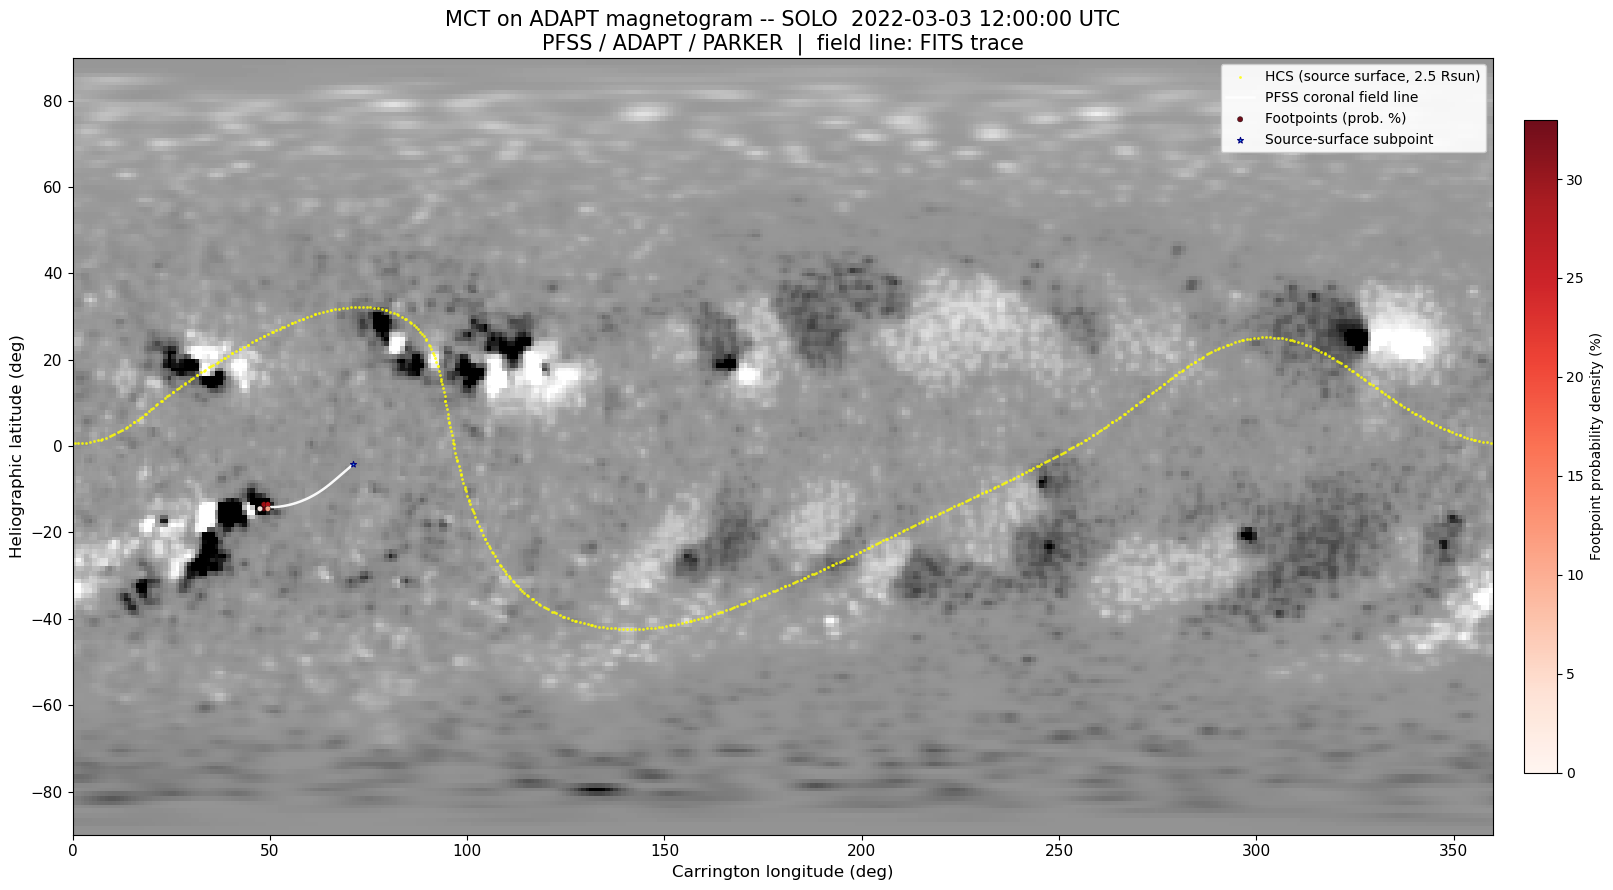

In [25]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
from astropy.io import fits
from astropy.table import Table


# ------------------------------------------------------------------
# 1. Read IRAP MCT fieldline FITS
# ------------------------------------------------------------------
RSUN_KM = 695700.0

def parse_fieldline_fits(path):
    with fits.open(path) as hdul:
        if len(hdul) < 2:
            raise RuntimeError("FITS file does not contain a table extension.")
        tab = Table(hdul[1].data).to_pandas()

    required = ["curv", "r", "lon", "lat", "br", "blon", "blat"]
    missing = [c for c in required if c not in tab.columns]
    if missing:
        raise RuntimeError(f"Missing expected columns in fieldline FITS: {missing}")

    df = pd.DataFrame({
        "curv": tab["curv"].astype(float),
        "r_km": tab["r"].astype(float),
        "R_Rsun": tab["r"].astype(float) / RSUN_KM,
        "lon_HGC_deg": np.mod(tab["lon"].astype(float), 360.0),
        "lat_HGC_deg": tab["lat"].astype(float),
        "br": tab["br"].astype(float),
        "blon": tab["blon"].astype(float),
        "blat": tab["blat"].astype(float),
    })
    return df


# ------------------------------------------------------------------
# 2. Split line when longitude jumps across 0/360 boundary
# ------------------------------------------------------------------
def split_line_on_lon_wrap(df, lon_col="lon_HGC_deg", sort_col="R_Rsun", threshold=180.0):
    if df is None or df.empty:
        return []

    work = df.sort_values(sort_col).reset_index(drop=True)
    segments = []
    start = 0

    for i in range(1, len(work)):
        dlon = abs(work.loc[i, lon_col] - work.loc[i - 1, lon_col])
        if dlon > threshold:
            seg = work.iloc[start:i].copy()
            if len(seg) > 0:
                segments.append(seg)
            start = i

    last_seg = work.iloc[start:].copy()
    if len(last_seg) > 0:
        segments.append(last_seg)

    return segments


# ------------------------------------------------------------------
# 3. Plot function
# ------------------------------------------------------------------
def plot_mct_on_adapt_mag_with_fieldline_fits(
    mct_files: dict,
    sc_info: dict,
    footpoints_df: pd.DataFrame,
    params: dict,
    meta: dict,
    fieldline_fits_path: str,
    title_suffix: str = "",
    figsize=(18, 9),
):
    mag_raw = get_ascii_text(mct_files, "backgroundmag")
    if mag_raw is None:
        raise RuntimeError("No backgroundmag PNG found in ZIP.")

    hcs_raw = get_ascii_text(mct_files, "filehcs")
    if hcs_raw is None:
        raise RuntimeError("No filehcs.ascii found in ZIP.")

    mag_img = Image.open(io.BytesIO(mag_raw)).convert("RGBA")
    hcs_df = parse_hcs(hcs_raw).sort_values("lon_deg").reset_index(drop=True)

    fieldline_df = parse_fieldline_fits(fieldline_fits_path)
    fl = fieldline_df.sort_values("R_Rsun").reset_index(drop=True)
    fl_segments = split_line_on_lon_wrap(fl, lon_col="lon_HGC_deg", sort_col="R_Rsun", threshold=180.0)

    fp_end = fl.iloc[0]   # near photosphere
    ss_end = fl.iloc[-1]  # near source surface

    fig, ax = plt.subplots(figsize=figsize)

    # background magnetogram
    ax.imshow(
        mag_img,
        extent=[0.0, 360.0, -90.0, 90.0],
        origin="upper",
        aspect="auto",
        interpolation="nearest",
        zorder=0,
    )

    # HCS
    ax.scatter(
        hcs_df["lon_deg"],
        hcs_df["lat_deg"],
        s=4,
        c="yellow",
        alpha=0.85,
        linewidths=0,
        zorder=2,
        label="HCS (source surface, 2.5 Rsun)",
    )

    # PFSS field line
    for i, seg in enumerate(fl_segments):
        ax.plot(
            seg["lon_HGC_deg"],
            seg["lat_HGC_deg"],
            color="white",
            linewidth=1.8,
            alpha=0.95,
            zorder=4,
            label="PFSS coronal field line" if i == 0 else None,
        )

    # # Fieldline endpoints: smaller and visually distinct
    # ax.scatter(
    #     fp_end["lon_HGC_deg"],
    #     fp_end["lat_HGC_deg"],
    #     s=45,
    #     marker="o",
    #     c="deepskyblue",
    #     edgecolors="black",
    #     linewidths=0.7,
    #     zorder=6,
    #     label="Fieldline photosphere end",
    # )
    # ax.scatter(
    #     ss_end["lon_HGC_deg"],
    #     ss_end["lat_HGC_deg"],
    #     s=50,
    #     marker="s",
    #     c="cyan",
    #     edgecolors="black",
    #     linewidths=0.7,
    #     zorder=6,
    #     label="Fieldline source-surface end",
    # )

    # Footpoints: smaller, and probability higher -> darker red
    max_p = float(footpoints_df["prob_pct"].max())
    norm = mcolors.Normalize(vmin=0.0, vmax=max_p)

    fp_sc = ax.scatter(
        footpoints_df["lon_HGC_deg"],
        footpoints_df["lat_HGC_deg"],
        c=footpoints_df["prob_pct"],
        cmap="Reds",
        norm=norm,
        s=15,
        marker="o",
        edgecolors="black",
        linewidths=0.25,
        alpha=0.95,
        zorder=5,
        label="Footpoints (prob. %)",
    )
    cbar = fig.colorbar(fp_sc, ax=ax, shrink=0.84, pad=0.018)
    cbar.set_label("Footpoint probability density (%)")

    # # Highest-probability footpoint
    # best = footpoints_df.loc[footpoints_df["prob_pct"].idxmax()]
    # ax.scatter(
    #     best["lon_HGC_deg"],
    #     best["lat_HGC_deg"],
    #     s=120,
    #     marker="D",
    #     facecolors="lime",
    #     edgecolors="black",
    #     linewidths=0.9,
    #     zorder=7,
    #     label="Highest-prob. footpoint",
    # )

    # Source-surface subpoints: plot only one legend entry
    ss_sub = params["source_surface_subpoints"]
    first = True
    for sw, ss_v in ss_sub.items():
        ax.scatter(
            ss_v["lon_HGC_deg"],
            ss_v["lat_HGC_deg"],
            s=20,
            marker="*",
            c="dodgerblue",
            edgecolors="navy",
            linewidths=0.8,
            zorder=7,
            label="Source-surface subpoint" if first else None,
        )
        first = False

    ax.set_xlim(0.0, 360.0)
    ax.set_ylim(-90.0, 90.0)
    ax.set_xlabel("Carrington longitude (deg)", fontsize=12)
    ax.set_ylabel("Heliographic latitude (deg)", fontsize=12)
    ax.set_title(
        f"MCT on ADAPT magnetogram -- {sc_info['name']}  {sc_info['obs_time']} UTC\n"
        f"{meta.get('coronal_model')} / {meta.get('mag_input')} / {meta.get('helio_model')}"
        f"  |  field line: FITS trace"
        + title_suffix,
        fontsize=15,
    )

    ax.tick_params(labelsize=11)
    ax.legend(loc="upper right", fontsize=10, framealpha=0.92)
    plt.tight_layout()

    return fig, ax, fieldline_df


# ------------------------------------------------------------------
# 4. Run
# ------------------------------------------------------------------
fieldline_fits_path = "../data/SOLO_PARKER_PFSS_SCTIME_ADAPT_SCIENCE_20220303T120000_filefieldline.fits"

fig, ax, fieldline_df = plot_mct_on_adapt_mag_with_fieldline_fits(
    mct_files=mct_files,
    sc_info=sc_info,
    footpoints_df=footpoints_df,
    params=params,
    meta=meta,
    fieldline_fits_path=fieldline_fits_path,
    figsize=(18, 9),
)

plt.show()

In [ ]:
import requests
from pathlib import Path


def download_mct_fieldline_fits_direct(
    spacecraft="SOLO",
    coronal="ADAPT",
    interplanetary="PARKER",
    mode="SCTIME",
    date="2022-03-03",
    time="120000",
    outpath="mct_fieldline.fits",
    timeout=60,
):
    """
    Download IRAP MCT fieldline FITS directly from static/temporary,
    without using the /api zip endpoint.
    """

    # Based on observed filename patterns on the MCT site:
    # current/forecast pages -> ..._FORECAST_...
    # historical science products -> ..._SCIENCE_...
    #
    # coronal type in filenames appears as PFSS for ADAPT/WSO/NSO products
    # and mag input is the selected magnetogram/model input (e.g. ADAPT).
    datestr = date.replace("-", "") + "T" + time

    candidates = [
        f"https://connect-tool.irap.omp.eu/static/temporary/"
        f"{spacecraft}_{interplanetary}_PFSS_{mode}_{coronal}_SCIENCE_{datestr}_filefieldline.fits",

        f"https://connect-tool.irap.omp.eu/static/temporary/"
        f"{spacecraft}_{interplanetary}_PFSS_{mode}_{coronal}_FORECAST_{datestr}_filefieldline.fits",
    ]

    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0",
        "Accept": "*/*",
        "Referer": "https://connect-tool.irap.omp.eu/",
    })

    last_error = None

    for url in candidates:
        try:
            r = session.get(url, stream=True, timeout=timeout, allow_redirects=True)

            # Some endpoints may return HTML error pages with 200/400-like behavior,
            # so check both status and content-type / filename.
            content_type = r.headers.get("Content-Type", "").lower()
            disposition = r.headers.get("Content-Disposition", "").lower()

            ok_binary = (
                r.status_code == 200
                and (
                    "fits" in content_type
                    or "octet-stream" in content_type
                    or ".fits" in disposition
                    or url.lower().endswith(".fits")
                )
            )

            if ok_binary:
                outpath = Path(outpath)
                with open(outpath, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)
                return str(outpath), url

            last_error = (
                f"URL tried: {url}\n"
                f"status={r.status_code}, content-type={content_type}, "
                f"content-disposition={disposition}"
            )

        except Exception as e:
            last_error = f"URL tried: {url}\nexception={e}"

    raise RuntimeError(
        "Failed to download fieldline FITS directly.\n"
        + (last_error or "No candidate URL succeeded.")
    )

fieldline_path, fieldline_url = download_mct_fieldline_fits_direct(
    spacecraft="SOLO",
    coronal="ADAPT",
    interplanetary="PARKER",
    mode="SCTIME",
    date="2022-03-03",
    time="120000",
    outpath="SOLO_20220303T120000_fieldline.fits",
)

print("Downloaded:", fieldline_path)
print("From:", fieldline_url)

In [2]:
def read_connectivity(path):
    """Read MCT *_fileconnectivity.ascii -> (sc_line_dict, rows_list)."""
    lines = [
        ln.split()
        for ln in open(path, encoding="utf-8", errors="replace")
        if ln.strip() and not ln.strip().startswith("#")
    ]
    t = lines[2][0] + " " + lines[2][1]
    sc = {"name": lines[3][0], "time": t, "R_m": float(lines[3][1]),
          "lat": float(lines[3][2]), "lon": float(lines[3][3])}
    n = int(lines[4][0])
    rows = []
    for p in lines[5 : 5 + n]:
        rows.append({
            "type": p[0], "prob": float(p[2]),
            "lat": float(p[4]), "lon": float(p[5]),
        })
    return sc, rows

sc, rows = read_connectivity('../data/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_fileconnectivity.ascii')

In [4]:
sc

{'name': 'SOLO',
 'time': '2022-03-03 12:00:00',
 'R_m': 81621668200.0,
 'lat': -4.15165608,
 'lon': 46.6840677}

In [3]:
rows

[{'type': 'SSW', 'prob': 13.0, 'lat': -14.25, 'lon': 49.5},
 {'type': 'SSW', 'prob': 10.0, 'lat': -13.75, 'lon': 49.5},
 {'type': 'SSW', 'prob': 9.0, 'lat': -14.75, 'lon': 48.5},
 {'type': 'SSW', 'prob': 6.0, 'lat': -15.25, 'lon': 48.5},
 {'type': 'SSW', 'prob': 6.0, 'lat': -15.25, 'lon': 49.5},
 {'type': 'SSW', 'prob': 5.0, 'lat': -16.25, 'lon': 49.5},
 {'type': 'SSW', 'prob': 5.0, 'lat': -10.75, 'lon': 56.5},
 {'type': 'SSW', 'prob': 4.0, 'lat': -16.75, 'lon': 49.5},
 {'type': 'SSW', 'prob': 4.0, 'lat': -15.75, 'lon': 49.5},
 {'type': 'SSW', 'prob': 4.0, 'lat': -10.75, 'lon': 57.5},
 {'type': 'SSW', 'prob': 3.0, 'lat': -12.75, 'lon': 50.5},
 {'type': 'SSW', 'prob': 3.0, 'lat': 13.75, 'lon': 119.5},
 {'type': 'SSW', 'prob': 2.0, 'lat': -14.75, 'lon': 49.5},
 {'type': 'SSW', 'prob': 2.0, 'lat': -13.25, 'lon': 49.5},
 {'type': 'SSW', 'prob': 2.0, 'lat': -10.75, 'lon': 55.5},
 {'type': 'SSW', 'prob': 2.0, 'lat': 13.25, 'lon': 119.5},
 {'type': 'SSW', 'prob': 1.0, 'lat': -18.25, 'lon': 48